# SMITH RIBOMap and STARmap transfer

This notebook extracts the SMITH transfer results for modality-matched RIBOMap references and cross-modality STARmap references from a pinned five-seed benchmark table. It preserves the reported uncertainty and ranking rather than copying values into prose.

[Open the editable source notebook on GitHub](https://github.com/fym0503/SMITH/blob/main/docs/source/tutorials/notebooks/ribomap_section/03_SMITH_RIBOMap_Transfer_source.ipynb)

## Setup

Run this notebook from a cloned SMITH repository with `pip install -e '.[notebooks]'`. All inputs are checksum-validated before analysis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "reproducibility").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside a SMITH repository checkout.")


ROOT = find_repository(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

from smith.reproducibility import check_case, load_cases, run_case

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
print(f"Repository: {ROOT}")


Repository: /workspace/fanyimin/SMITH_package


In [2]:
CASE_ID = "03_ribomap_transfer"
case = load_cases()[CASE_ID]
status = check_case(case)
if status["inputs"]:
    display(pd.DataFrame(status["inputs"])[["path", "exists", "sha256_ok"]])
else:
    print("This tutorial creates its deterministic input during execution.")
assert status["ready"], "The pinned tutorial inputs are missing or have changed."

output_dir = ROOT / "outputs" / "notebooks" / CASE_ID
result = run_case(case, output_dir)
print(f"Summary written to: {result['summary_json']}")
result


,path,exists,sha256_ok
0,/workspace/fanyimin/SMITH_package/reproducibil...,True,True


Summary written to: /workspace/fanyimin/SMITH_package/outputs/notebooks/03_ribomap_transfer/summary.json


{'case': '03_ribomap_transfer',
 'title': 'Cross-study and cross-modality RIBOMap transfer',
 'manuscript_section': 'SMITH Transfers Panel Design to Spatial Translatome Profiling',
 'figure': 'Figure 4',
 'claim': 'Transcriptomic and translatomic references provide distinct but useful priors for translatome panel design.',
 'smith_transfer_metrics': [{'dataset': 'ribo_deep_to_rep2',
   'label': 'celltype',
   'panel_size': 128,
   'value_mean': 0.3148138683022404,
   'value_std': 0.0037677894422176,
   'rank': 1.0},
  {'dataset': 'ribo_deep_to_rep2',
   'label': 'region',
   'panel_size': 128,
   'value_mean': 0.4664111082715734,
   'value_std': 0.0031532679669633,
   'rank': 1.0},
  {'dataset': 'starmap_rep2_to_rep2',
   'label': 'celltype',
   'panel_size': 128,
   'value_mean': 0.3432489990629525,
   'value_std': 0.0047340041912691,
   'rank': 1.0},
  {'dataset': 'starmap_rep2_to_rep2',
   'label': 'region',
   'panel_size': 128,
   'value_mean': 0.5136042252321322,
   'value_std': 

## Analysis

,dataset,label,panel_size,value_mean,value_std,rank
0,ribo_deep_to_rep2,celltype,128,0.314814,0.003768,1.0
1,ribo_deep_to_rep2,region,128,0.466411,0.003153,1.0
2,starmap_rep2_to_rep2,celltype,128,0.343249,0.004734,1.0
3,starmap_rep2_to_rep2,region,128,0.513604,0.002496,1.0


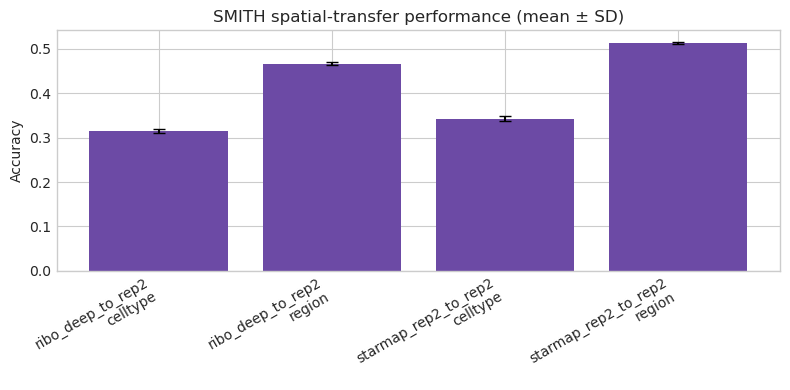

In [3]:
transfer = pd.DataFrame(result["smith_transfer_metrics"])
display(transfer)

labels = transfer["dataset"] + "\n" + transfer["label"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(transfer)), transfer["value_mean"],
       yerr=transfer["value_std"], capsize=4, color="#6c4aa5")
ax.set_xticks(np.arange(len(transfer)), labels, rotation=30, ha="right")
ax.set(ylabel="Accuracy", title="SMITH spatial-transfer performance (mean ± SD)")
fig.tight_layout()
plt.show()


## What this reproduces

This notebook recomputes the manuscript-facing SMITH accuracy summary and its uncertainty. Complete Figure 4 regeneration also requires raw spatial objects, baseline selection, pathway enrichment, panel-overlap analysis, and aligned clean-fusion experiments.